# Task 2 — Yelp Polarity sentiment, three models from scratch (Chaitanya)

This notebook loads the artifacts produced by the scripts in this folder and shows them with outputs, plus a few
live checks (preprocessing, model sanity checks, re-scoring a checkpoint). Everything is produced by one command
(about 10 minutes on an RTX 4090):

| Step | Script |
|---|---|
| Aswin's split, verified; HF row indices | `make_splits.py` |
| Preprocessing, EDA, vocabulary, encodings | `preprocess.py` (config `configs/data.yaml`) |
| Slice tags (ours + Aswin's) | `slices.py` (definitions `configs/slices.yaml`) |
| 3 models × seeds 42/43/44 | `run_all_training.py` → `train.py --config configs/<model>.yaml --seed <s>` |
| TF-IDF + LR reference row | `tfidf_reference.py` |
| All metrics, McNemar, slices, team comparison, plots | `evaluate.py` |
| Error-review candidates | `errors.py` |
| **Everything** | `python task2_sentiment/member_chaitanya/src/run_pipeline.py` |

Design decisions and their rationale: `results.md`.

In [1]:
import json, sys, pickle, warnings
from pathlib import Path
warnings.filterwarnings("ignore")  # library warnings would print local install paths

SRC = Path.cwd() if (Path.cwd() / 'models.py').exists() else Path('task2_sentiment/member_chaitanya/src').resolve()
sys.path.insert(0, str(SRC))
import numpy as np, pandas as pd, torch
from IPython.display import Image, display
from common import MEMBER_DIR, OUTPUTS_DIR, PROCESSED_DIR, SPLITS_DIR, CHECKPOINTS_DIR, load_config, read_json
pd.set_option('display.max_columns', None); pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 120)
cfgs = {k: load_config(f'task2_sentiment/member_chaitanya/configs/{k}.yaml') for k in ('baseline', 'experimental_1', 'experimental_2')}
data_cfg = load_config('task2_sentiment/member_chaitanya/configs/data.yaml')['data']
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

cuda NVIDIA GeForce RTX 4090


## 2.1 Data preprocessing
### Split: Aswin's split reproduced and verified, plus the 33K complement

In [2]:
m = read_json(SPLITS_DIR / 'split_manifest.json')
print(json.dumps(m['verification'], indent=1))
pd.DataFrame(m['splits']).T[['hf_split', 'n', 'n_pos']]

{
 "test5k_text_matches_aswin_predictions_in_order": "5000/5000",
 "test5k_label_matches": "5000/5000",
 "aswin_vocab_fingerprint": "18766 (Aswin reports 18766)",
 "text_overlap_train25k_vs_hf_test": 0
}


,hf_split,n,n_pos
train,train,20000,10000
val,train,5000,2500
test5k,test,5000,2500
test33k,test,33000,16500


### Length distribution, class balance, missing / malformed entries

,train,val,test5k,test33k
n,20000,5000,5000,33000
class_counts,"{'0': 10000, '1': 10000}","{'0': 2500, '1': 2500}","{'0': 2500, '1': 2500}","{'0': 16500, '1': 16500}"
missing_text,0,0,0,0
non_string,0,0,0,0
empty_or_whitespace,0,0,0,0
label_not_0_1,0,0,0,0
duplicate_texts_within_split,0,0,0,0
empty_after_cleaning,2,0,0,0
raw_words_mean,133.3,133.2,131.0,132.8
raw_words_median,96.0,97.0,97.0,97.0


cross-split duplicate texts (vs train): {'val': 0, 'test5k': 0, 'test33k': 0}
vocabulary: {'size': 19646, 'min_freq': 2, 'max_vocab': 30000, 'train_types': 35365}


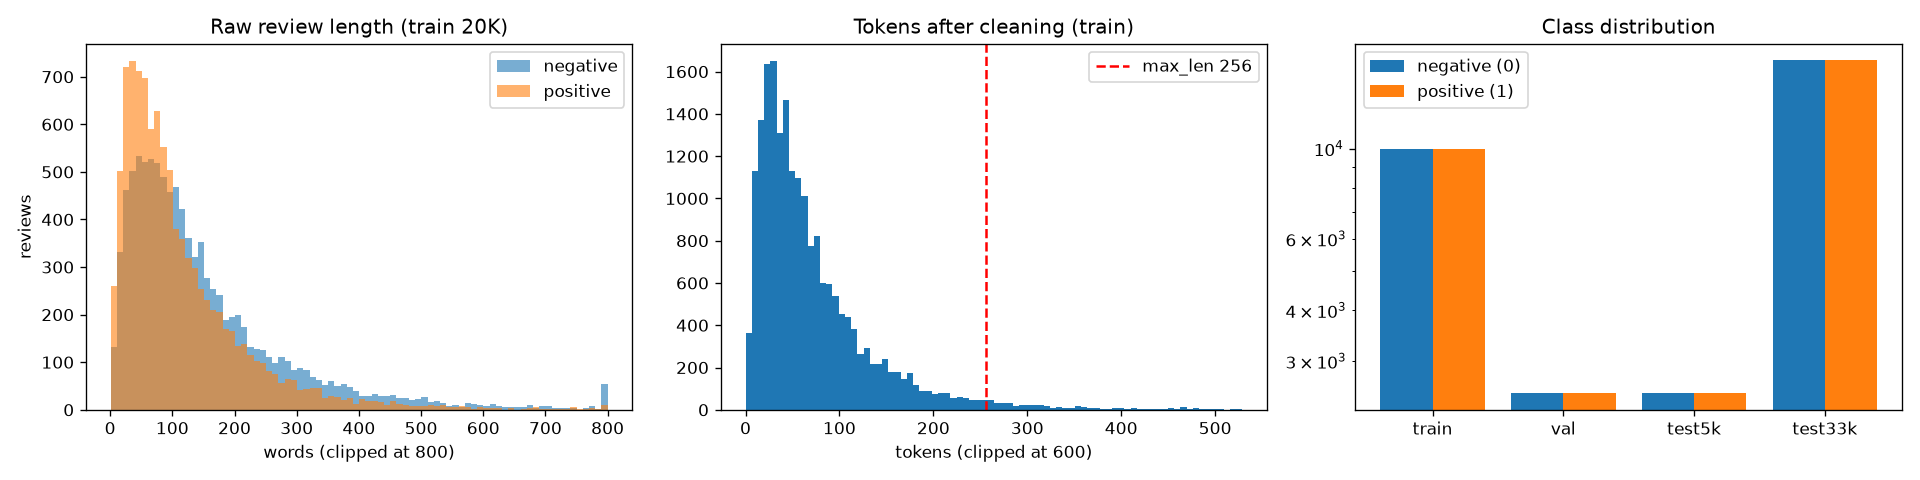

In [3]:
eda = read_json(OUTPUTS_DIR / 'eda' / 'eda_summary.json')
cols = ['n', 'class_counts', 'missing_text', 'non_string', 'empty_or_whitespace', 'label_not_0_1', 'duplicate_texts_within_split',
        'empty_after_cleaning', 'raw_words_mean', 'raw_words_median', 'raw_words_p95', 'raw_words_max', 'raw_words_by_class_median',
        'clean_tokens_median', 'pct_truncated_over_max_len', 'pct_over_max_sentences', 'oov_token_rate']
display(pd.DataFrame(eda['splits']).loc[cols])
print('cross-split duplicate texts (vs train):', eda['cross_split_duplicate_texts'])
print('vocabulary:', eda['vocab'])
display(Image(str(OUTPUTS_DIR / 'eda' / 'length_distribution.png')))

### Text preprocessing (live): contractions → punctuation removal → POS tag → stopwords (negations kept) → lemmatisation

In [4]:
import preprocess as P
P._init_worker()
for t in ["I didn't like it. The fries weren't great, but the service was very friendly!\\nWon't come back... dont go",
          "Best tacos in town!!! My boss's favorite caf\\u00e9. We were dining at 7pm; it's the worst parking though.",
          "Looks good from far but far from good."]:
    print(repr(t)); print('  ->', P.process_review(t)); print()
print('stopwords kept:', sorted(P.KEEP_STOPWORDS))

"I didn't like it. The fries weren't great, but the service was very friendly!\\nWon't come back... dont go"
  -> [['not', 'like'], ['fry', 'not', 'great', 'but', 'service', 'very', 'friendly'], ['not', 'come', 'back'], ['not', 'go']]

"Best tacos in town!!! My boss's favorite caf\\u00e9. We were dining at 7pm; it's the worst parking though."
  -> [['best', 'taco', 'town'], ['boss', 'favorite', 'cafe'], ['dine', '7', 'pm', 'worst', 'parking', 'though']]

'Looks good from far but far from good.'
  -> [['looks', 'good', 'far', 'but', 'far', 'good']]

stopwords kept: ['against', 'but', 'few', 'however', 'never', 'no', 'nor', 'not', 'too', 'very']


### Tokenisation and encoding (vocabulary from the 20K train split only)

In [5]:
itos = read_json(PROCESSED_DIR / 'vocab.json')['itos']
z = np.load(PROCESSED_DIR / 'train.npz')
print('vocab size:', len(itos), '| first entries:', itos[:12])
print('flat input:', z['flat'].shape, '| HAN input:', z['hier'].shape, '| labels:', np.bincount(z['labels']))
raw = pickle.load(open(PROCESSED_DIR / 'train_tokens.pkl', 'rb'))[0]
print('review 0, cleaned sentences:', [' '.join(s) for s in raw][:4])
print('review 0, flat ids:', z['flat'][0][:20].tolist())
print('review 0, HAN ids (2 sentences):', z['hier'][0][:2, :10].tolist())

vocab size: 19646 | first entries: ['<pad>', '<unk>', 'not', 'but', 'get', 'go', 'place', 'food', 'good', 'like', 'would', 'time']


flat input: (20000, 256) | HAN input: (20000, 32, 32) | labels: [10000 10000]
review 0, cleaned sentences: ['brand new place open today', 'interior bright welcome friendly staff put best foot forward new business ought', 'hubby ran get 6 pack cupcake family snarffled could rightly choose flavor', 'one yellow butter cream frosting mighty tasty']


review 0, flat ids: [932, 98, 6, 152, 363, 1102, 1468, 838, 97, 72, 162, 58, 608, 694, 98, 202, 5671, 1125, 6438, 4]
review 0, HAN ids (2 sentences): [[932, 98, 6, 152, 363, 0, 0, 0, 0, 0], [1102, 1468, 838, 97, 72, 162, 58, 608, 694, 98]]


## 2.2 Models
Shared embedding layer (128-d, from scratch) in all three; attention is written by hand.

In [6]:
from models import build_model, count_params
models = {k: build_model(c, len(itos)) for k, c in cfgs.items()}
for k, mdl in models.items():
    print(f'{k:15s} {cfgs[k]["model_name"]:25s} params {count_params(mdl):>12,}')
    assert not any(isinstance(m, (torch.nn.MultiheadAttention, torch.nn.TransformerEncoderLayer)) for m in mdl.modules())
print('no prebuilt attention / Transformer modules used')
print(models['experimental_1'])
print(models['experimental_2'])

baseline        baseline_fasttext_bigram  params   19,292,033
experimental_1  exp1_han                  params    2,746,753
experimental_2  exp2_transformer          params    2,944,385
no prebuilt attention / Transformer modules used
HAN(
  (embed): Embedding(19646, 128, padding_idx=0)
  (edrop): Dropout(p=0.3, inplace=False)
  (word_rnn): LSTM(128, 64, batch_first=True, bidirectional=True)
  (word_attn): AttentionPool(
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (sent_rnn): LSTM(128, 64, batch_first=True, bidirectional=True)
  (sent_attn): AttentionPool(
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (drop): Dropout(p=0.3, inplace=False)
  (out): Linear(in_features=128, out_features=1, bias=True)
)
TransformerClassifier(
  (embed): Embedding(19646, 128, padding_idx=0)
  (edrop): Dropout(p=0.3, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): 

In [7]:
# sanity check: adding / removing padding must not change the output (masking works) for every model
torch.manual_seed(0)
for k, mdl in models.items():
    mdl.eval()
    x = torch.from_numpy(z['hier' if cfgs[k]['input'] == 'hier' else 'flat'][:4].astype(np.int64))
    if cfgs[k]['input'] == 'hier':
        x2 = torch.zeros(4, 40, 32, dtype=torch.long); x2[:, :32] = x          # 8 extra empty sentences
    else:
        x2 = x[:, : int((x != 0).sum(1).max())]                                  # trailing padding removed
    with torch.no_grad():
        a, b = mdl(x), mdl(x2)
    print(f'{k:15s} max |logit diff| with extra padding: {(a - b).abs().max().item():.2e}')

baseline        max |logit diff| with extra padding: 0.00e+00


experimental_1  max |logit diff| with extra padding: 0.00e+00


experimental_2  max |logit diff| with extra padding: 0.00e+00


### Training runs (3 seeds each; early stopping on validation macro-F1, best epoch restored)

,run_id,param_count,best_epoch,epochs_run,best_val_macro_f1,train_time_s,train_examples_per_sec,peak_memory_mb,hardware
0,t2_baseline_s42,19292033,2,5,0.928800,6.074044,16463.495532,698.250000,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
1,t2_baseline_s43,19292033,2,5,0.927199,6.069257,16476.481331,698.250000,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
2,t2_baseline_s44,19292033,2,5,0.927599,6.104645,16380.967601,698.250000,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
3,t2_exp1_han_s42,2746753,2,5,0.918765,49.008522,2040.461461,387.399902,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
4,t2_exp1_han_s43,2746753,1,4,0.917345,39.288061,2036.241995,387.915527,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
5,t2_exp1_han_s44,2746753,2,5,0.919395,48.549913,2059.735909,386.940918,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
6,t2_exp2_transformer_s42,2944385,3,6,0.905172,16.520650,7263.636866,1535.368652,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
7,t2_exp2_transformer_s43,2944385,3,6,0.906590,16.541145,7254.636809,1535.368652,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"
8,t2_exp2_transformer_s44,2944385,3,6,0.906168,16.559402,7246.638501,1535.368652,"GPU: NVIDIA GeForce RTX 4090; CPU: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD"


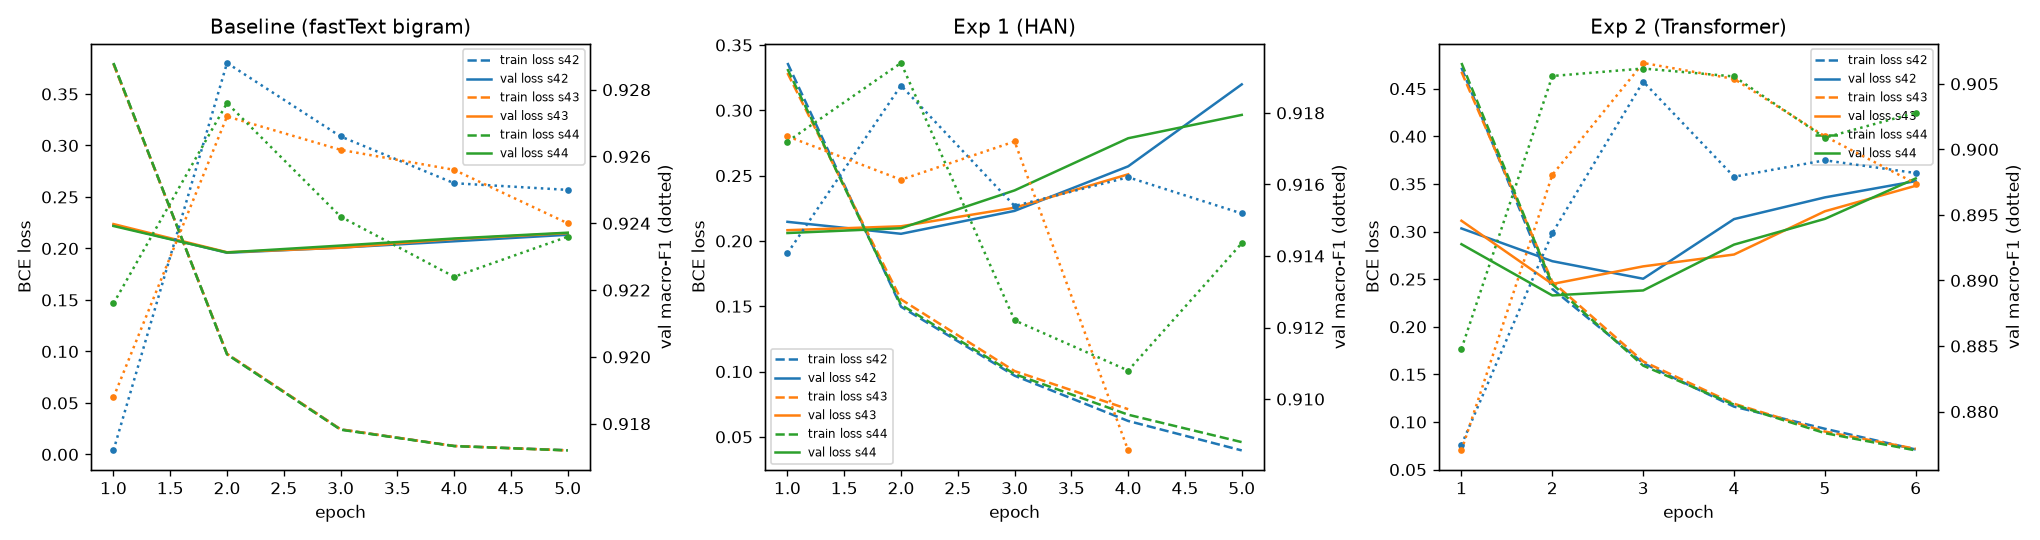

In [8]:
rows = []
for k, c in cfgs.items():
    for s in c['seeds']:
        t = read_json(OUTPUTS_DIR / 'runs' / f"{c['run_prefix']}_s{s}" / 'train_summary.json')
        rows.append({k2: t[k2] for k2 in ('run_id', 'param_count', 'best_epoch', 'epochs_run', 'best_val_macro_f1', 'train_time_s',
                                          'train_examples_per_sec', 'peak_memory_mb', 'hardware')})
display(pd.DataFrame(rows))
display(Image(str(OUTPUTS_DIR / 'plots' / 'training_curves.png')))

### Live check: reload the seed-42 checkpoints and re-score test5k; must match the saved predictions

In [9]:
from train import load_set, predict
for k, c in cfgs.items():
    run = f"{c['run_prefix']}_s42"
    mdl = build_model(c, len(itos)).to(device)
    mdl.load_state_dict(torch.load(CHECKPOINTS_DIR / run / 'best.pt', map_location=device)['model'])
    x, y, _ = load_set('test5k', c['input'])
    p = predict(mdl, x, device)
    saved = pd.read_csv(OUTPUTS_DIR / 'runs' / run / 'pred_test5k.csv')['prob_pos'].to_numpy()
    print(f'{run:24s} accuracy {((p >= 0.5) == y.numpy()).mean():.4f}   max |p - saved| {np.abs(p - saved).max():.1e}')

t2_baseline_s42          accuracy 0.9294   max |p - saved| 3.0e-08


t2_exp1_han_s42          accuracy 0.9286   max |p - saved| 3.0e-08


t2_exp2_transformer_s42  accuracy 0.9128   max |p - saved| 3.0e-08


## 2.2 Evaluation — full metrics (seed 42; 95% bootstrap CIs, 2,000 resamples; threshold 0.5)

In [10]:
rep = pd.read_csv(MEMBER_DIR / 'metrics_report.csv')
display(rep.set_index(['model', 'eval_set']).T)

model                                                                                 Baseline (fastText bigram)  \
eval_set                                                                                                  test5k   
run_id                                                                                           t2_baseline_s42   
checkpoint                                                                   checkpoints/t2_baseline_s42/best.pt   
accuracy                                                                                                  0.9294   
acc_ci_low                                                                                                0.9218   
acc_ci_high                                                                                               0.9362   
precision_macro                                                                                          0.92943   
recall_macro                                                                                              0.9294   
f1_macro                                                                                                0.929399   
f1_macro_ci_low                                                                                         0.921793   
f1_macro_ci_high                                                                                        0.936172   
precision_micro                                                                                           0.9294   
recall_micro                                                                                              0.9294   
f1_micro                                                                                                  0.9294   
precision_weighted                                                                                       0.92943   
recall_weighted                                                                                           0.9294   
f1_weighted                                                                                             0.929399   
tn                                                                                                          2334   
fp                                                                                                           166   
fn                                                                                                           187   
tp                                                                                                          2313   
roc_auc                                                                                                 0.978616   
pr_auc                                                                                                  0.979155   
mcc                                                                                                      0.85883   
mcc_ci_low                                                                                                0.8436   
mcc_ci_high                                                                                             0.872391   
brier                                                                                                   0.054309   
ece                                                                                                     0.013747   
mcnemar_vs_baseline_stat                                                                                     NaN   
mcnemar_vs_baseline_p                                                                                        NaN   
param_count                                                                                             19292033   
train_time_s                                                                                            6.074044   
examples_per_sec                                                                                    16463.495532   
peak_memory_mb                                          

In [11]:
print('Training variance over seeds 42/43/44 (mean ± std):')
display(pd.read_csv(OUTPUTS_DIR / 'seed_summary.csv'))
print('McNemar, baseline vs each model (seed 42):')
display(pd.read_csv(OUTPUTS_DIR / 'mcnemar.csv'))

Training variance over seeds 42/43/44 (mean ± std):


,model,eval_set,seeds,accuracy_mean,f1_macro_mean,mcc_mean,roc_auc_mean,pr_auc_mean,brier_mean,ece_mean,accuracy_std,f1_macro_std,mcc_std,roc_auc_std,pr_auc_std,brier_std,ece_std,best_epochs
0,Baseline (fastText bigram),test5k,"42,43,44",0.929533,0.929532,0.859105,0.978414,0.978951,0.054183,0.014061,0.000115,0.000115,0.000239,0.000266,0.000180,0.000109,0.000836,"2,2,2"
1,Baseline (fastText bigram),test33k,"42,43,44",0.926879,0.926876,0.853820,0.976640,0.976098,0.055527,0.014231,0.000440,0.000439,0.000911,0.000131,0.000126,0.000166,0.000558,"2,2,2"
2,Exp 1 (HAN),test5k,"42,43,44",0.925133,0.925109,0.850798,0.979760,0.980852,0.055276,0.013857,0.005001,0.005017,0.009708,0.001384,0.001413,0.002978,0.000698,"2,1,2"
3,Exp 1 (HAN),test33k,"42,43,44",0.919788,0.919765,0.840046,0.976638,0.977472,0.059508,0.013253,0.002494,0.002500,0.004885,0.000734,0.000870,0.000985,0.005281,"2,1,2"
4,Exp 2 (Transformer),test5k,"42,43,44",0.915133,0.915118,0.830576,0.973585,0.974775,0.064567,0.033177,0.003870,0.003860,0.007944,0.000671,0.000309,0.002911,0.010042,"3,3,3"
5,Exp 2 (Transformer),test33k,"42,43,44",0.910646,0.910626,0.821675,0.970801,0.971429,0.068005,0.033798,0.000350,0.000359,0.000540,0.000145,0.000090,0.001218,0.007946,"3,3,3"


McNemar, baseline vs each model (seed 42):


,eval_set,model_a,model_b,a_right_b_wrong,a_wrong_b_right,statistic,p_value,test
0,test5k,Baseline (fastText bigram),Exp 1 (HAN),153,149,0.029801,8.629418e-01,chi2 with continuity correction
1,test5k,Baseline (fastText bigram),Exp 2 (Transformer),184,101,23.592982,1.190208e-06,chi2 with continuity correction
2,test5k,Baseline (fastText bigram),Reference: TF-IDF + LR (uncounted),68,96,4.445122,3.500109e-02,chi2 with continuity correction
3,test33k,Baseline (fastText bigram),Exp 1 (HAN),1066,925,9.844299,1.703589e-03,chi2 with continuity correction
4,test33k,Baseline (fastText bigram),Exp 2 (Transformer),1214,700,137.496865,9.389136e-32,chi2 with continuity correction
5,test33k,Baseline (fastText bigram),Reference: TF-IDF + LR (uncounted),438,622,31.593396,1.900749e-08,chi2 with continuity correction


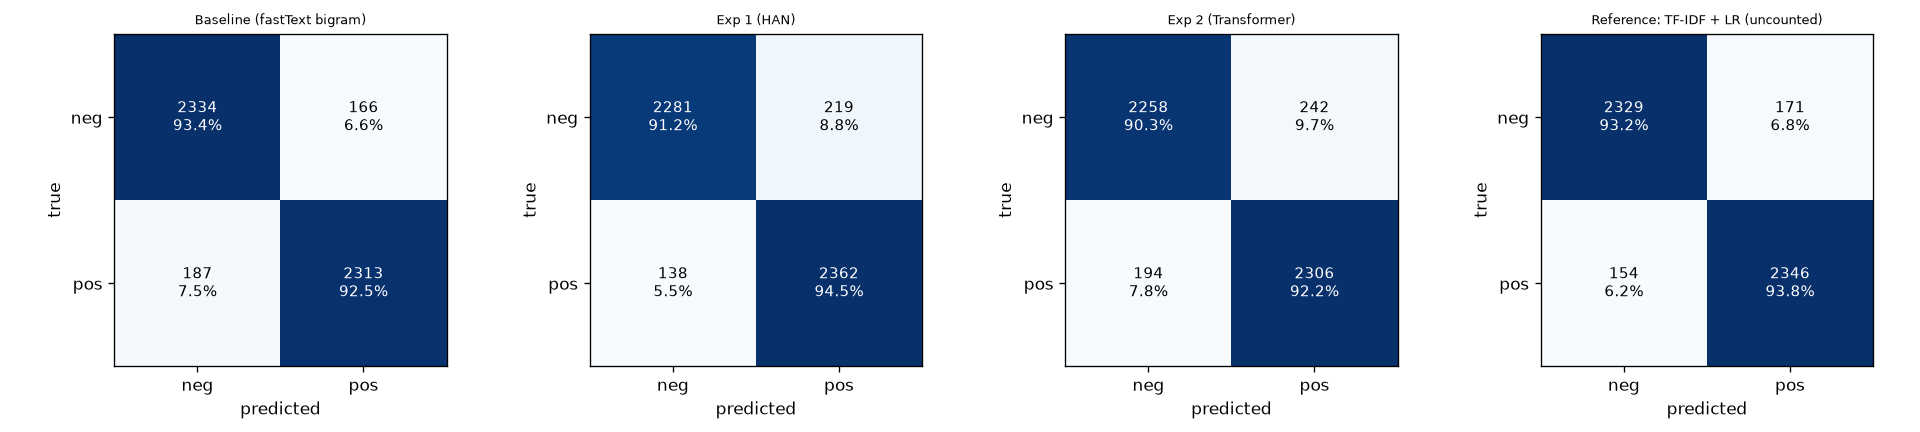

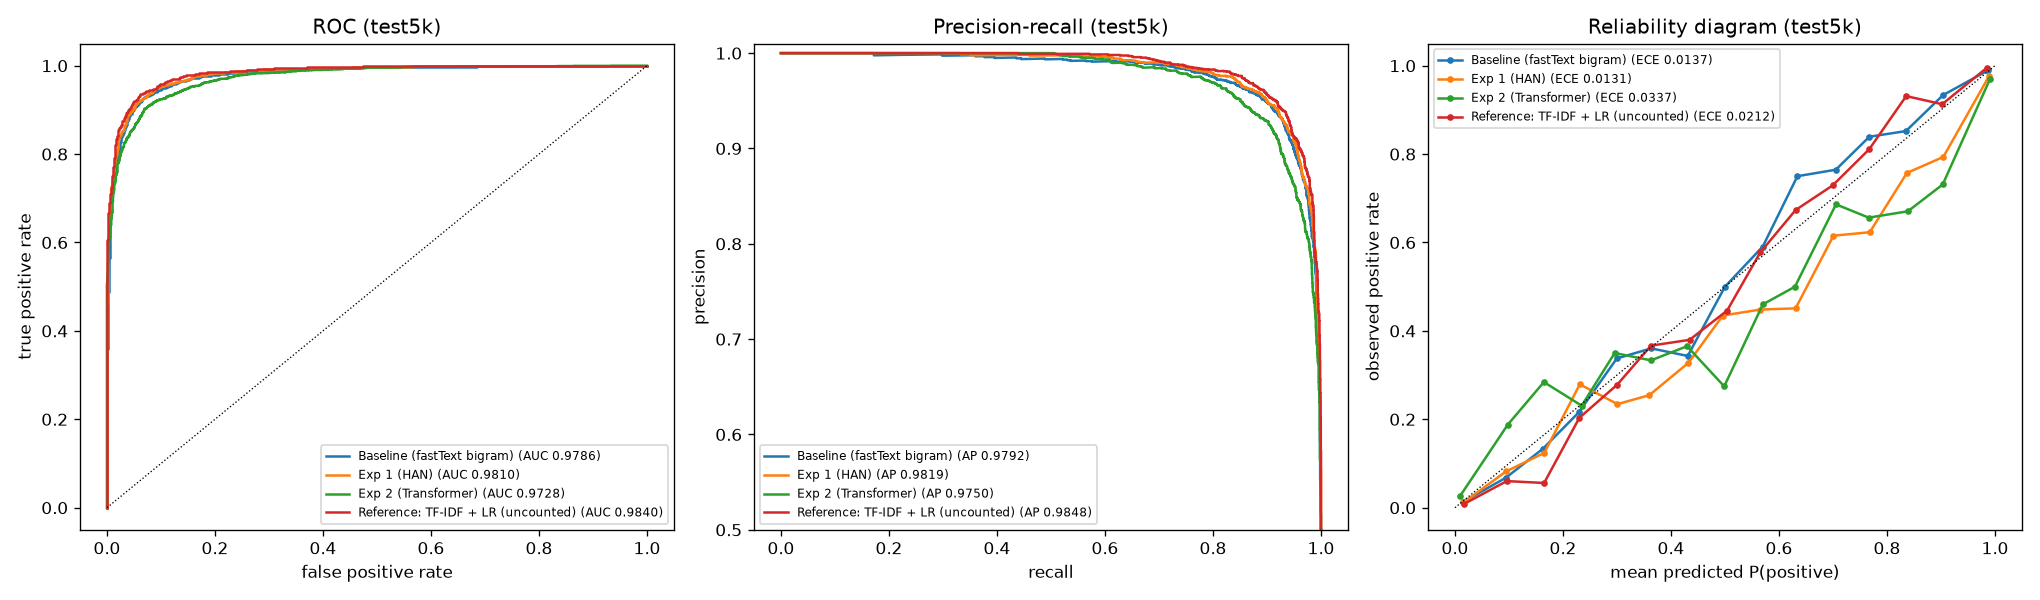

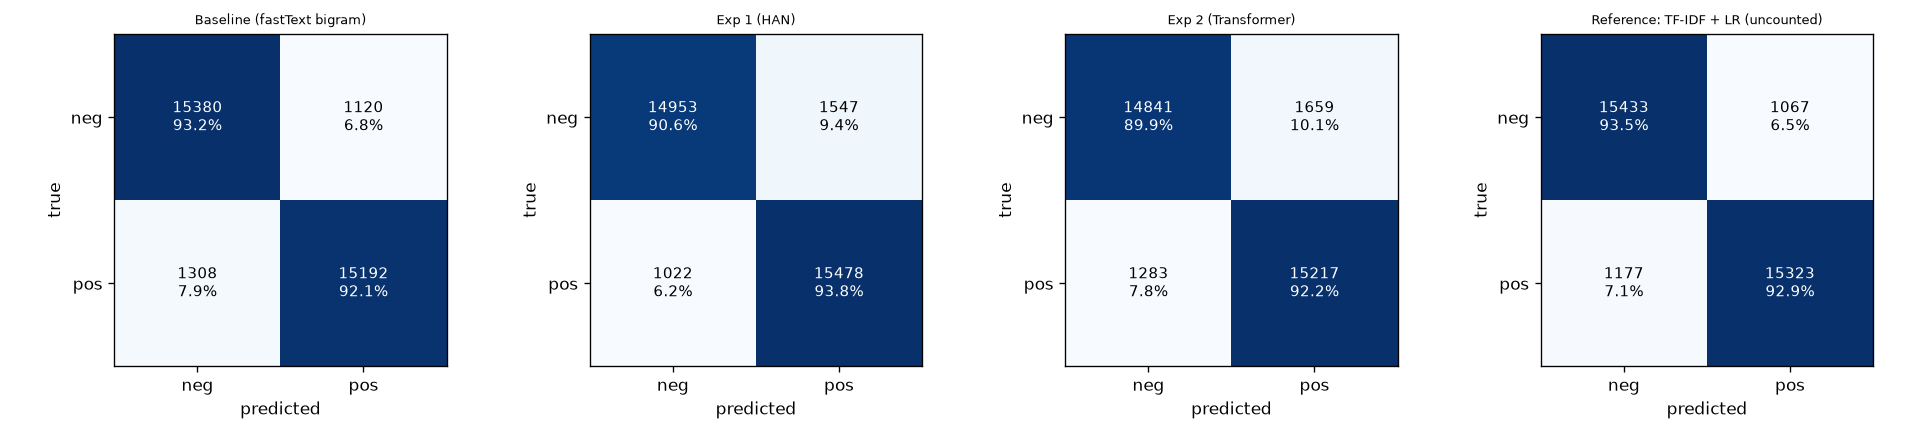

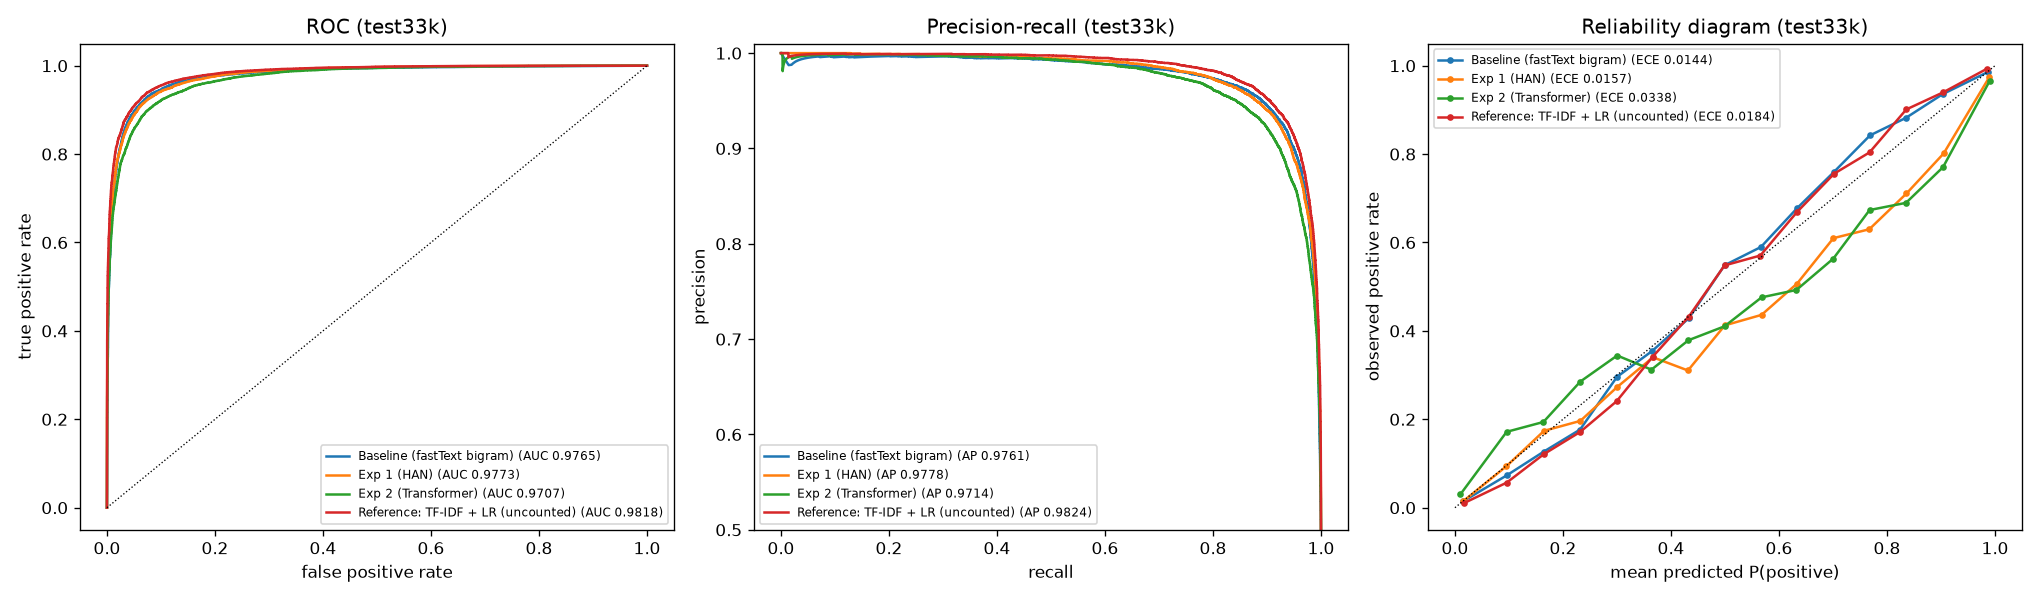

In [12]:
for s in ('test5k', 'test33k'):
    display(Image(str(OUTPUTS_DIR / 'plots' / f'confusion_matrices_{s}.png')))
    display(Image(str(OUTPUTS_DIR / 'plots' / f'roc_pr_reliability_{s}.png')))

### Robustness: macro-F1 per slice (ours `C:` and Aswin's `A:`; slices with n < 150 not reported)

In [13]:
sl = pd.read_csv(OUTPUTS_DIR / 'slice_metrics.csv')
for s in ('test5k', 'test33k'):
    t = sl[sl.eval_set == s].pivot_table(index='slice', columns='model', values='macro_f1', sort=False)
    t.insert(0, 'n', sl[sl.eval_set == s].groupby('slice', sort=False).n.first())
    print(s); display(t.round(4))

test5k


model,n,Baseline (fastText bigram),Exp 1 (HAN),Exp 2 (Transformer),Reference: TF-IDF + LR (uncounted),Aswin baseline (mean-pool FFN),Aswin exp 1 (BiGRU),Aswin exp 2 (TextCNN)
slice,,,,,,,,
C: short (<=60 words),1512,0.9247,0.9288,0.9066,0.9298,0.9130,0.9148,0.9218
C: medium (61-180 words),2328,0.9313,0.9304,0.9180,0.9381,0.9154,0.9257,0.9321
C: long (>180 words),1160,0.9259,0.9200,0.9035,0.9301,0.9150,0.9057,0.9098
C: negation,3688,0.9278,0.9244,0.9065,0.9330,0.9119,0.9143,0.9240
C: contrast,2919,0.9221,0.9222,0.9055,0.9285,0.9064,0.9092,0.9187
C: no strong polarity words,1918,0.8933,0.8903,0.8737,0.9037,0.8723,0.8810,0.8878
C: explicit rating mention,470,0.9149,0.9221,0.8959,0.9215,0.8927,0.8859,0.9113
A: Short Reviews (<50 words),1199,0.9220,0.9256,0.9066,0.9286,0.9142,0.9144,0.9149
A: Medium Reviews (50-150 words),2255,0.9330,0.9343,0.9188,0.9397,0.9188,0.9224,0.9361


test33k


model,n,Baseline (fastText bigram),Exp 1 (HAN),Exp 2 (Transformer),Reference: TF-IDF + LR (uncounted)
slice,,,,,
C: short (<=60 words),10058,0.9238,0.9208,0.9044,0.9293
C: medium (61-180 words),15078,0.9272,0.9225,0.9124,0.9314
C: long (>180 words),7864,0.9200,0.9158,0.9063,0.9291
C: truncated (>256 cleaned tokens),745,0.9000,0.8782,0.8802,0.9302
C: negation,24223,0.9211,0.9166,0.9024,0.9272
C: contrast,19414,0.9172,0.9125,0.8997,0.9233
C: no strong polarity words,12785,0.8946,0.8897,0.8723,0.9015
C: explicit rating mention,2962,0.9193,0.8986,0.8990,0.9331
A: Short Reviews (<50 words),7923,0.9224,0.9204,0.9021,0.9273


## 2.3 Team comparison on the shared test5k (Aswin's committed predictions, same rows, same code)

In [14]:
display(pd.read_csv(OUTPUTS_DIR / 'team_comparison.csv'))
display(pd.read_csv(OUTPUTS_DIR / 'team_mcnemar.csv'))

,member,model,accuracy,f1_macro,mcc,roc_auc,pr_auc,brier,ece,fp,fn,acc_ci,f1_macro_ci,mcc_ci
0,chaitanya,Baseline (fastText bigram),0.9294,0.929399,0.858830,0.978616,0.979155,0.054309,0.013747,166,187,"[0.9218, 0.9362]","[0.9218, 0.9362]","[0.8436, 0.8724]"
1,chaitanya,Exp 1 (HAN),0.9286,0.928581,0.857650,0.981048,0.981936,0.053664,0.013060,219,138,"[0.9218, 0.9354]","[0.9217, 0.9354]","[0.8440, 0.8713]"
2,chaitanya,Exp 2 (Transformer),0.9128,0.912792,0.825752,0.972811,0.975040,0.066777,0.033740,242,194,"[0.9050, 0.9206]","[0.9049, 0.9206]","[0.8100, 0.8413]"
3,aswin,Aswin baseline (mean-pool FFN),0.9162,0.916200,0.832405,0.973736,0.974106,0.060515,0.011798,205,214,"[0.9082, 0.9234]","[0.9082, 0.9233]","[0.8164, 0.8467]"
4,aswin,Aswin exp 1 (BiGRU),0.9194,0.919384,0.839138,0.975553,0.976608,0.060965,0.017538,166,237,"[0.9118, 0.9266]","[0.9118, 0.9266]","[0.8241, 0.8534]"
5,aswin,Aswin exp 2 (TextCNN),0.9252,0.925194,0.850544,0.979972,0.980430,0.055574,0.015948,210,164,"[0.9178, 0.9320]","[0.9178, 0.9320]","[0.8358, 0.8640]"


,model_a,model_b,a_right_b_wrong,a_wrong_b_right,statistic,p_value,test,p_holm
0,Baseline (fastText bigram),Aswin baseline (mean-pool FFN),164,98,16.125954,0.000059,chi2 with continuity correction,0.000533
1,Baseline (fastText bigram),Aswin exp 1 (BiGRU),174,124,8.057047,0.004533,chi2 with continuity correction,0.027196
2,Baseline (fastText bigram),Aswin exp 2 (TextCNN),197,176,1.072386,0.300407,chi2 with continuity correction,0.901221
3,Exp 1 (HAN),Aswin baseline (mean-pool FFN),201,139,10.944118,0.000939,chi2 with continuity correction,0.007512
4,Exp 1 (HAN),Aswin exp 1 (BiGRU),195,149,5.886628,0.015256,chi2 with continuity correction,0.076281
5,Exp 1 (HAN),Aswin exp 2 (TextCNN),188,171,0.713092,0.398419,chi2 with continuity correction,0.901221
6,Exp 2 (Transformer),Aswin baseline (mean-pool FFN),150,167,0.807571,0.368839,chi2 with continuity correction,0.901221
7,Exp 2 (Transformer),Aswin exp 1 (BiGRU),149,182,3.093656,0.078598,chi2 with continuity correction,0.314392
8,Exp 2 (Transformer),Aswin exp 2 (TextCNN),173,235,9.120098,0.002528,chi2 with continuity correction,0.017697


## Error review candidates (baseline, seed 42, test5k) — labels in `failure_analysis.md`

In [15]:
pd.read_csv(OUTPUTS_DIR / 'error_review' / 'baseline_candidates.csv')[['n', 'category', 'label', 'pred', 'prob_pos', 'slices', 'text']]

,n,category,label,pred,prob_pos,slices,text
0,1,Confident FP,0,1,9.996278e-01,short (<=60 words),Average Japanese food at amazing Japanese food prices.
1,2,Confident FP,0,1,9.971803e-01,short (<=60 words); no strong polarity words,"Second trip to the bar v ased on a promo of free play. Gambling was good, great Pandora music, and plenty of tv. B..."
2,3,Confident FP,0,1,9.947562e-01,short (<=60 words); explicit rating mention,How do they get 5 stars? My fianc\u00e9 was disappointed as well. The funkiest looking pad Thai ever.
3,4,Confident FP,0,1,9.937180e-01,short (<=60 words),"I would recommend you the potatoes soup or clam chowder they are awesome... services is ok, kind of slow during lunc..."
4,5,Confident FP,0,1,9.926196e-01,short (<=60 words); contrast; no strong polarity words,Looks good from far but far from good.
5,6,Confident FN,1,0,1.321054e-07,short (<=60 words); no strong polarity words,Decent!
6,7,Confident FN,1,0,2.234328e-04,short (<=60 words); no strong polarity words,Sunday buffet for $13 all you can eat and drink.
7,8,Confident FN,1,0,1.860651e-03,short (<=60 words); negation; no strong polarity words; explicit rating mention,"I've just been forced to concede that, despite still not digging their ordering process, their food is just too good..."
8,9,Confident FN,1,0,1.964941e-03,short (<=60 words); contrast; no strong polarity words,"Its a nice buffet looking over the Aria pool, but variety was just ok.... Meh.."
9,10,Confident FN,1,0,6.894494e-03,short (<=60 words); negation; no strong polarity words,"If you don't \""""get it,\"""" I'm \""""sorry.\""""\n\nPeel Pub... I shall forever *heart* you.\n\n_C$"
